In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=32
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014008()
subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.781 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


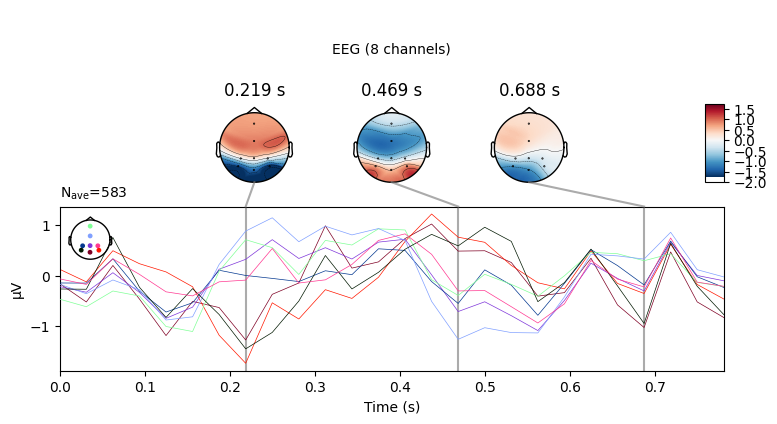

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
tmin = epochs.tmin
sfreq = epochs.info['sfreq']

def hankel_tensor(X, y=None):    
    window = .4
    max_lag = .4
    
    n_epochs, n_channels, _ = X.shape
    roi0 = int((0 - tmin)*sfreq)
    roi1 = int((window - tmin)*sfreq)
    n_times = roi1-roi0
    n_lags= int(max_lag*sfreq)
    Xt = np.zeros((n_epochs, n_channels, n_times, n_lags))
    for l in range(n_lags):
        Xt[:,:,:,l] = X[:,:,roi0+l:roi1+l]
    return Xt

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from mne.decoding import Scaler

tl.set_backend('cupy')


X = epochs.get_data(picks='eeg')
split = len(epochs)//2
X_train = X[:split]
X_test = X[split:]
y_train = labels[:split]
y_test = labels[split:]




scaler = Scaler(scalings='mean', with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = tl.tensor(hankel_tensor(X_train))
X_test = tl.tensor(hankel_tensor(X_test))

In [17]:
from hoda.hoda import BTTDA, shrink, oas, HODA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


n_blocks=3
bttda_lda = Pipeline([
    ('bttda', BTTDA(
        n_blocks=n_blocks,
        hoda_params=dict(
                rank=[8,8,8],
                max_iter=64,
                tol=1e-3,
                init ='mlsvd',
                verbose=True,
                shrinkage=(0,0,0),
                toeplitz=None,
                solver='ratio_svd',
                keep_train_info=True,
        ),
        verbose=True)
    ),
    ('lda', LinearDiscriminantAnalysis())
])

bttda_lda.fit(X_train,y_train)

Fitting block 1/3...


/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'


  0%|          | 0/64 [00:00<?, ?it/s]

Fit tucker model of rank [8, 8, 8]

Fitting block 2/3...


  0%|          | 0/64 [00:00<?, ?it/s]

Fit tucker model of rank [8, 8, 8]

Fitting block 3/3...


  0%|          | 0/64 [00:00<?, ?it/s]

Fit tucker model of rank [8, 8, 8]



Pipeline(steps=[('bttda',
                 BTTDA(hoda_params={'init': 'mlsvd', 'keep_train_info': True,
                                    'max_iter': 64, 'rank': [8, 8, 8],
                                    'shrinkage': (0, 0, 0),
                                    'solver': 'ratio_svd', 'toeplitz': None,
                                    'tol': 0.001, 'verbose': True},
                       n_blocks=3, verbose=True)),
                ('lda', LinearDiscriminantAnalysis())])

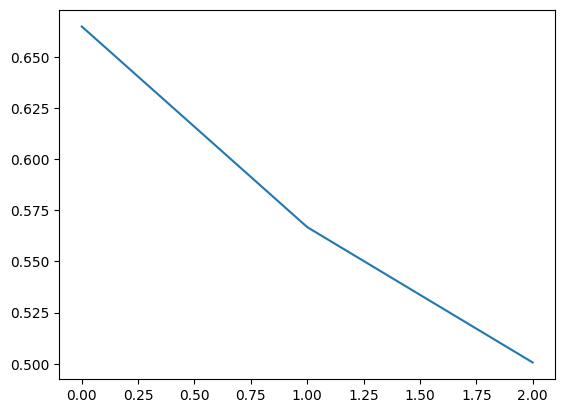

In [18]:
plt.plot(bttda_lda['bttda'].train_mse_)

<AxesSubplot: xlabel='score', ylabel='Count'>

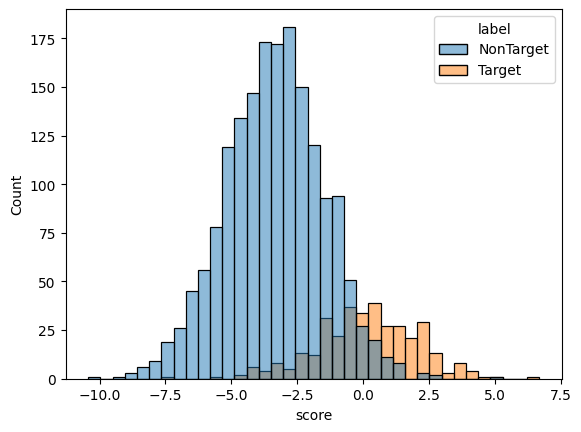

In [19]:
import pandas as pd
import cupy as cupy

train_scores = cupy.asnumpy(bttda_lda.decision_function(X_train))
df = pd.DataFrame(dict(score=cupy.asnumpy(train_scores),label=y_train))
sns.histplot(data=df, x='score', hue='label')

In [20]:
roc_auc_score(y_train,train_scores)

0.906675918367347

<AxesSubplot: xlabel='score', ylabel='Count'>

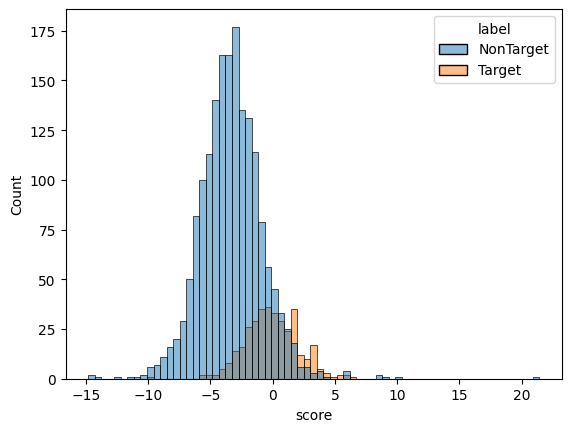

In [21]:
import pandas as pd

test_scores = cupy.asnumpy(bttda_lda.decision_function(X_test))
df = pd.DataFrame(dict(score=cupy.asnumpy(test_scores),label=y_test))
sns.histplot(data=df, x='score', hue='label')

In [22]:
roc_auc_score(y_test,test_scores)

0.8515036734693878